<a href="https://colab.research.google.com/github/Kate6097/train/blob/main/%D0%9D%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA%20%D1%81%20%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5%D0%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
# Установка дополнительных библиотек
!pip install Ninja

# Импорт нужных библиотек
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.utils import save_image
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

!pip install pydrive2

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-_6ui2obw
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-_6ui2obw
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


In [ ]:
import copy

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

!git clone https://github.com/rosinality/stylegan2-pytorch.git
%cd stylegan2-pytorch

!pip install ninja

import os
os.environ['STYLEGAN2_PYTORCH_FORCE_PURE'] = '1'
print(f"STYLEGAN2_PYTORCH_FORCE_PURE set to: {os.environ.get('STYLEGAN2_PYTORCH_FORCE_PURE')}")

import sys

print(f"Current working directory: {os.getcwd()}")


from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

print("Authenticating to Google Drive...")
auth.authenticate_user()
gauth = GoogleAuth()
try:
    gauth.credentials = GoogleCredentials.get_application_default()
except Exception as e:
    print(f"Error getting application default credentials: {e}")
    print("Attempting direct Colab auth for PyDrive2...")
    gauth.auth_method = 'colab'
    gauth.Authenticate()

drive = GoogleDrive(gauth)

ids = ['1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT', '1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL']
downloaded_files_paths = []

for file_id in ids:
    try:
        print(f"Downloading file with ID: {file_id}...")
        downloaded = drive.CreateFile({'id': file_id})
        downloaded.FetchMetadata(fetch_all=True)
        file_title = downloaded.metadata['title']
        print(f"Fetching content for: {file_title}")
        downloaded.GetContentFile(file_title)
        downloaded_files_paths.append(file_title)
        print(f"Successfully downloaded: {file_title}")
    except Exception as e:
        print(f"Failed to download file with ID {file_id}. Error: {e}")

print("Files in current directory:", os.listdir("."))

try:
    from model import Generator
    print("Successfully imported Generator from model.py")
except ImportError as e:
    print(f"Failed to import Generator: {e}")
    print("Please ensure model.py is in the current working directory and sys.path is correct.")

    raise

latent_dim = 512
generator_frozen = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)

# Создаем второй генератор (обучаемый)
generator_trainable = copy.deepcopy(generator_frozen).to(device)


checkpoint_path = 'stylegan2-ffhq-config-f.pt'
if not os.path.exists(checkpoint_path):
    print(f"ERROR: Checkpoint file '{checkpoint_path}' not found in the current directory!")
    print("Please check the downloaded file names.")

    if downloaded_files_paths:
        print(f"Attempting to use downloaded file: {downloaded_files_paths[0]}")
        checkpoint_path = downloaded_files_paths[0]
        if not os.path.exists(checkpoint_path):
             raise FileNotFoundError(f"Checkpoint file '{checkpoint_path}' still not found.")
    else:
        raise FileNotFoundError("No files were downloaded, cannot load checkpoint.")


print(f"Loading state_dict from: {checkpoint_path}")
state_dict = torch.load(checkpoint_path, map_location=device)

generator_frozen.load_state_dict(state_dict['g_ema'] if 'g_ema' in state_dict else state_dict)
generator_frozen.eval()  # Переводим в режим оценки

generator_trainable.load_state_dict(state_dict['g_ema'] if 'g_ema' in state_dict else state_dict)
generator_trainable.train()  # Переводим в режим обучения

# Замораживаем параметры первого генератора
for param in generator_frozen.parameters():
    param.requires_grad_(False)

print("Генератор StyleGAN2 загружены.")

Using device: cuda
fatal: destination path 'stylegan2-pytorch' already exists and is not an empty directory.
/content/stylegan2-pytorch
STYLEGAN2_PYTORCH_FORCE_PURE set to: 1
Current working directory: /content/stylegan2-pytorch
Authenticating to Google Drive...
Fetching content for: stylegan2-ffhq-config-f.pt
Successfully downloaded: stylegan2-ffhq-config-f.pt
Fetching content for: model_ir_se50.pth
Successfully downloaded: model_ir_se50.pth
Files in current directory: ['closed_form_factorization.py', 'model.py', 'dataset.py', 'apply_factor.py', 'sample', 'train.py', 'model_ir_se50.pth', 'factor_index-13_degree-5.0.png', 'non_leaking.py', 'projector.py', 'op', 'README.md', 'LICENSE-FID', 'LICENSE-NVIDIA', 'doc', 'lpips', 'calc_inception.py', 'distributed.py', 'convert_weight.py', 'generate.py', '.git', 'LICENSE', '__pycache__', 'inception_ffhq.pkl', 'fid.py', 'LICENSE-LPIPS', 'inception.py', 'ppl.py', '.gitignore', 'swagan.py', 'stylegan2-ffhq-config-f.pt', 'prepare_data.py', 'checkpo

/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Successfully imported Generator from model.py
Loading state_dict from: stylegan2-ffhq-config-f.pt
Генератор StyleGAN2 загружены.


/content/stylegan2-pytorch/op/conv2d_gradfix.py:88: UserWarning: conv2d_gradfix not supported on PyTorch 2.6.0+cu124. Falling back to torch.nn.functional.conv2d().
  warnings.warn(


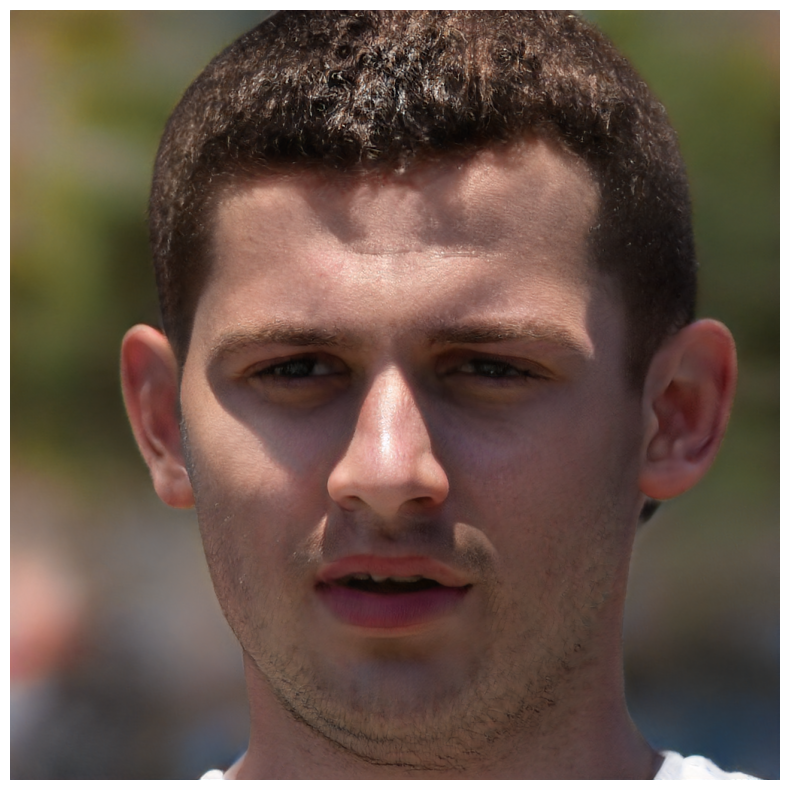

In [ ]:
# Сгенерируем изображение
latent_z = torch.randn(10000, 512, device=device)
latent_z_generated = latent_z.mean(0, keepdim=True)

with torch.no_grad():
  target_img, _ = generator_frozen([latent_z_generated], input_is_latent=False)

def tensor_to_image(tensor):
    img = tensor[0].permute(1, 2, 0).cpu().numpy()  # Изменение порядка каналов и преобразование в numpy
    img = (img + 1) / 2  # Нормализация из [-1, 1] в [0, 1]
    img = np.clip(img, 0, 1)  # Гарантируем корректный диапазон
    return img

def visual(image):
    # Визуализация
    plt.figure(figsize=(10, 10))
    plt.imshow(tensor_to_image(target_img))
    plt.axis('off')
    plt.show()

visual(tensor_to_image(target_img))

In [ ]:
class CLIPLoss(torch.nn.Module):
    """
    Этот класс определяет пользовательскую функцию потерь на основе CLIP
    Он измеряет сходство между изображением и текстовым описанием.
    """

    def __init__(self, stylegan_size=1024):
        """
        Инициализирует класс CLIPLoss.

        Args:
            opts: Объект, содержащий различные параметры, включая размер изображения StyleGAN.
        """
        super(CLIPLoss, self).__init__()
        # Загружаем предварительно обученную модель CLIP и функцию предварительной обработки
        self.model, self.preprocess = clip.load("ViT-B/32", device="cuda")

        self.upsample = torch.nn.Upsample(scale_factor=7)
        self.avg_pool = torch.nn.AvgPool2d(kernel_size=stylegan_size // 32)

    def forward(self, image, text):
        """
        Вычисляет потери CLIP между изображением и текстом

        Args:
            image: Входной тензор изображения
            text: Тензор текстового описания на выходе

        Returns:
            Значение потерь CLIP
        """
        image_embed = self.model.encode_image(image)

        text_embed = self.model.encode_text(text)     # [1, 512]

        # Нормализуем эмбеддинги
        image_embed = image_embed / image_embed.norm(dim=1, keepdim=True)
        text_embed = text_embed / text_embed.norm(dim=1, keepdim=True)

        # Вычисляем косинусную схожесть
        similarity = (image_embed @ text_embed.T).squeeze()  # [1]
        loss = 1 - similarity  # Минимизируем это значение
        return loss

In [ ]:
clip_loss = CLIPLoss()

100%|███████████████████████████████████████| 338M/338M [00:12<00:00, 29.0MiB/s]


In [ ]:
class Direction_loss(torch.nn.Module):
    def __init__(self, stylegan_size=1024):
        super().__init__()
        self.model, _ = clip.load("ViT-B/32", device=device)
        self.resize = Resize((224, 224))
        self.normalize = Normalize(
            mean=[0.48145466, 0.4578275, 0.40821073],
            std=[0.26862954, 0.26130258, 0.27577711]
        )

    def forward(self, t_source, t_target, img_trainable, img_frozen, beta=1):

        # Подготовка для CLIP
        clip_frozen = self.normalize(self.resize(img_frozen))
        clip_trainable = self.normalize(self.resize(img_trainable))

        # Текстовая разница
        T = beta*(self.model.encode_text(t_target) - self.model.encode_text(t_source))

        # Визуальная разница
        I = self.model.encode_image(clip_trainable) - self.model.encode_image(clip_frozen)

        # Косинусное расстояние (нормализация как в clip происходит под капотом)
        cos_sim = torch.cosine_similarity(I, T, dim=-1)
        return 1 - cos_sim.mean()


In [ ]:
from torchvision.transforms import Resize, Normalize

resize = Resize((224, 224))
normalize = Normalize(
    mean=[0.48145466, 0.4578275, 0.40821073],
    std=[0.26862954, 0.26130258, 0.27577711]
    )
import collections
import torch.nn as nn

def analyze_and_set_layers(generator, image, text, clip_loss, num_trainable=15):
    """
    АНАЛИЗИРУЕТ, какие модули (слои) самые важные, и устанавливает им
    requires_grad=True, а всем остальным — False.

    Аргументы:
    generator: ваш StyleGAN2 Generator.
    image: сгенерированное изображение.
    text: текстовое описание для CLIP (выход)
    clip_loss: функция для вычисления CLIP-лосса.
    num_trainable: количество модулей, которые нужно разморозить.
    """

    for param in generator.parameters():
        param.requires_grad_(True)
        param.grad = None

    #Вычисляем CLIP-лосс и градиенты по нему
    clip_image = normalize(resize(image))
    text_tensor = clip.tokenize([text]).to(image.device)
    clip_value = clip_loss(clip_image, text_tensor)
    clip_value.backward()

    #Собираем и агрегируем важность по логическим модулям
    module_importance = collections.defaultdict(float)
    module_param_count = collections.defaultdict(int)
    debug_module_contents = collections.defaultdict(list)

    target_module_types = (
        type(generator.conv1),
        type(generator.to_rgb1),
        type(generator.style[0]),
        type(generator.style[1]),
        type(generator.input)
    )

    # Проходимся по всем именованным модулям
    for module_name, module in generator.named_modules():
        if module_name == '':
            continue
        is_target_module = False
        if isinstance(module, target_module_types):
            is_target_module = True
        current_module_grad_sum = 0.0
        current_module_param_count = 0

        for param_name, param in module.named_parameters(recurse=False):
            if param.grad is not None:
                current_module_grad_sum += param.grad.abs().mean().item()
                current_module_param_count += 1
                debug_module_contents[module_name].append(f"{module_name}.{param_name}")

        if current_module_param_count > 0:
            module_importance[module_name] = current_module_grad_sum / current_module_param_count
            module_param_count[module_name] = current_module_param_count


    module_importance_new = collections.defaultdict(float)
    module_param_count_new = collections.defaultdict(int)
    debug_module_contents_new = collections.defaultdict(list)
    all_named_modules = dict(generator.named_modules())

    logical_layer_classes = []
    if hasattr(generator, 'conv1') and isinstance(generator.conv1, nn.Module):
        logical_layer_classes.append(type(generator.conv1)) # StyledConv
    if hasattr(generator, 'to_rgb1') and isinstance(generator.to_rgb1, nn.Module):
        logical_layer_classes.append(type(generator.to_rgb1)) # ToRGB
    if hasattr(generator.style, '0') and isinstance(generator.style[0], nn.Module):
        # PixelNorm or EqualLinear
        logical_layer_classes.append(type(generator.style[0]))
    if hasattr(generator, 'input') and isinstance(generator.input, nn.Module):
        logical_layer_classes.append(type(generator.input)) # ConstantInput

    # Дополнительно: EqualLinear из style MLP
    for i in range(len(generator.style)):
        if isinstance(generator.style[i], nn.Module) and type(generator.style[i]) not in logical_layer_classes:
            logical_layer_classes.append(type(generator.style[i])) # EqualLinear


    for name, param in generator.named_parameters():
        if param.grad is not None:
            parts = name.split('.')
            found_logical_module_name = None

            for i in range(len(parts)):
                sub_module_name = '.'.join(parts[:i+1])
                if sub_module_name in all_named_modules:
                    current_sub_module_instance = all_named_modules[sub_module_name]
                    if isinstance(current_sub_module_instance, tuple(logical_layer_classes)):
                        found_logical_module_name = sub_module_name
                        break
            if found_logical_module_name is None:

                if '.' in name:
                    found_logical_module_name = '.'.join(parts[:-1])
                else:
                    found_logical_module_name = name


            module_importance_new[found_logical_module_name] += param.grad.abs().mean().item()
            module_param_count_new[found_logical_module_name] += 1
            debug_module_contents_new[found_logical_module_name].append(name) # Для отладки

    # Вычисляем среднюю важность для каждого модуля (уже сделано в цикле для module_importance_new)
    for name in module_importance_new:
        module_importance_new[name] /= module_param_count_new[name]

    sorted_modules = sorted(module_importance_new.items(), key=lambda x: x[1], reverse=True)

    trainable_modules = {x[0] for x in sorted_modules[:num_trainable]}


    #print("\n--- НОВАЯ РАЗБИВКА ПО ЛОГИЧЕСКИМ МОДУЛЯМ (ИСПРАВЛЕНО) ---")
    #print("Разбивка по логическим модулям (имена модулей -> количество параметров):")
    #single_param_modules = []
    #for mod_name, param_list in debug_module_contents_new.items():
    #    if len(param_list) == 1:
    #        single_param_modules.append((mod_name, param_list[0]))
    #    print(f"  Модуль: '{mod_name}' -> Параметров: {len(param_list)}")

    #if single_param_modules:
    #    print("\nВНИМАНИЕ (НОВЫЙ ПОДХОД): Следующие 'модули' содержат только 1 параметр (это может быть нормально для PixelNorm/ConstantInput):")
    #    for mod_name, param_name in single_param_modules:
    #        print(f"  - Модуль '{mod_name}' содержит только параметр '{param_name}'")

    #print(f"\nВсего уникальных логических модулей, определенных для градиентов: {len(module_importance_new)}")
    #

    #замораживаем всё, а потом размораживаем только выбранные модули
    trainable_params_count = 0
    for name, param in generator.named_parameters():
        parts = name.split('.')
        current_param_logical_module = None
        for i in range(len(parts)):
            sub_module_name = '.'.join(parts[:i+1])
            if sub_module_name in all_named_modules:
                current_sub_module_instance = all_named_modules[sub_module_name]
                if isinstance(current_sub_module_instance, tuple(logical_layer_classes)):
                    current_param_logical_module = sub_module_name
                    break

        if current_param_logical_module is None:
            if '.' in name:
                current_param_logical_module = '.'.join(parts[:-1])
            else:
                current_param_logical_module = name


        is_trainable = current_param_logical_module in trainable_modules
        param.requires_grad_(is_trainable)
        if is_trainable:
            trainable_params_count += 1

    print(f"\nАнализ завершен. Выбрано для обучения {len(trainable_modules)} логических модулей (всего параметров: {trainable_params_count}).")

    return clip_value.item(), list(trainable_modules)

In [ ]:
direct_loss = Direction_loss()

In [ ]:
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
prompt1 = "photo"
prompt2 = "light sketch"

text_in = torch.cat([clip.tokenize(prompt1)]).to(device)
text_out = torch.cat([clip.tokenize(prompt2)]).to(device)


In [ ]:
#создание/пересоздание новых генераторов для экспериментов

generator_frozen = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)
generator_frozen.load_state_dict(state_dict['g_ema'] if 'g_ema' in state_dict else state_dict)

generator_trainable = copy.deepcopy(generator_frozen).to(device)
generator_trainable.load_state_dict(state_dict['g_ema'] if 'g_ema' in state_dict else state_dict)

generator_frozen.eval()
generator_trainable.train()

for param in generator_frozen.parameters():
    param.requires_grad_(False)


In [ ]:
def generate_latent_batch(batch_size, device, generator_style_network):
    """
    Генерирует батч латентных векторов в W+ пространстве,
    прогоняя случайные Z-векторы через style network.

    :param batch_size: Размер батча.
    :param device: Устройство (cuda/cpu).
    :param generator_style_network: Метод или модуль, который выполняет отображение Z -> W+.
                                    Например, generator_frozen.style.
    :return: Тензор латентных векторов в W+ пространстве [batch_size, 18, 512].
    """
    latent_z = torch.randn(batch_size, 512, device=device) # [B, 512]

    with torch.no_grad():
        latent_w_plus = generator_style_network(latent_z)
        # принимает [B, 512] и возвращает [B, 18, 512]

    # Отсоединяем от графа замороженного генератора и делаем копию,
    # чтобы tensor_trainable мог отслеживать градиенты по этому латентному вектору
    latent_batch = latent_w_plus.detach().clone()
    latent_batch.requires_grad = True
    return latent_batch



--- Шаг 0: Пересчёт важности слоёв ---

Анализ завершен. Выбрано для обучения 27 логических модулей (всего параметров: 122).
Активные слои: ['convs.9', 'to_rgbs.2', 'convs.2', 'to_rgbs.4', 'convs.4']...
Шаг 0: Тренировочный лосс = 9.6094


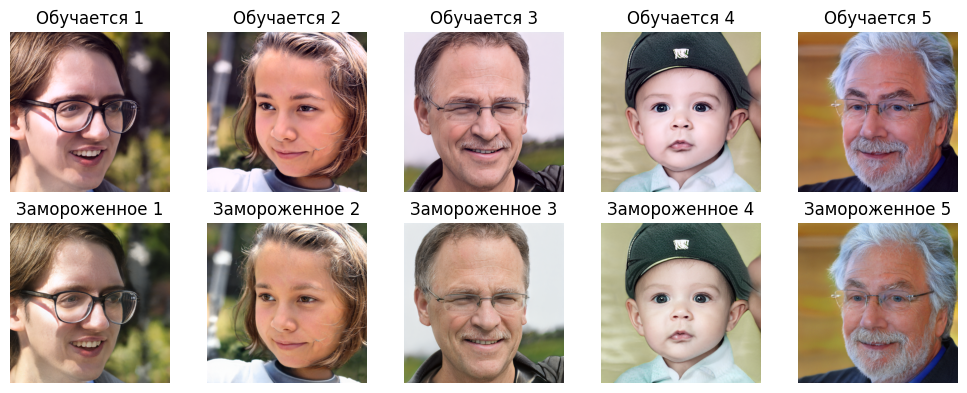


--- Шаг 50: Пересчёт важности слоёв ---

Анализ завершен. Выбрано для обучения 27 логических модулей (всего параметров: 122).
Активные слои: ['convs.9', 'to_rgbs.2', 'convs.2', 'to_rgbs.4', 'convs.4']...
Шаг 50: Тренировочный лосс = 5.5508


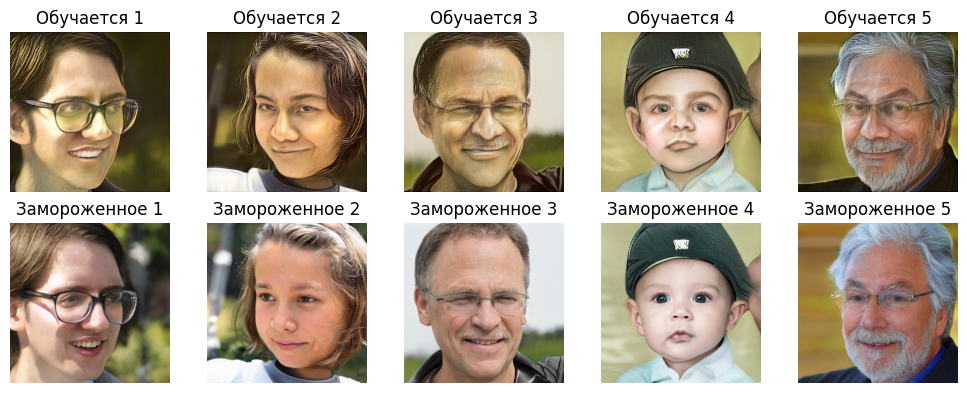


--- Шаг 100: Пересчёт важности слоёв ---

Анализ завершен. Выбрано для обучения 27 логических модулей (всего параметров: 122).
Активные слои: ['convs.9', 'to_rgbs.2', 'convs.2', 'to_rgbs.4', 'convs.4']...
Шаг 100: Тренировочный лосс = 5.2578


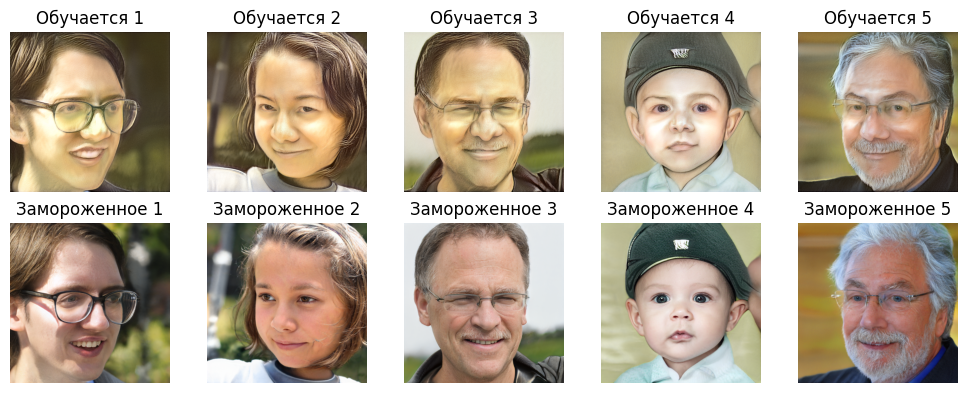


--- Шаг 150: Пересчёт важности слоёв ---

Анализ завершен. Выбрано для обучения 27 логических модулей (всего параметров: 122).
Активные слои: ['convs.9', 'to_rgbs.2', 'convs.2', 'to_rgbs.4', 'convs.4']...
Шаг 150: Тренировочный лосс = 4.9141


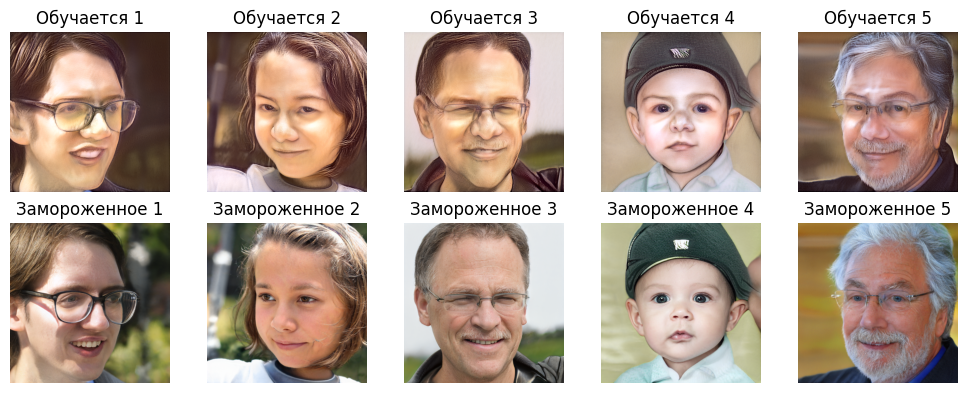


--- Шаг 200: Пересчёт важности слоёв ---

Анализ завершен. Выбрано для обучения 27 логических модулей (всего параметров: 122).
Активные слои: ['convs.9', 'to_rgbs.2', 'convs.2', 'to_rgbs.4', 'convs.4']...
Шаг 200: Тренировочный лосс = 4.6055


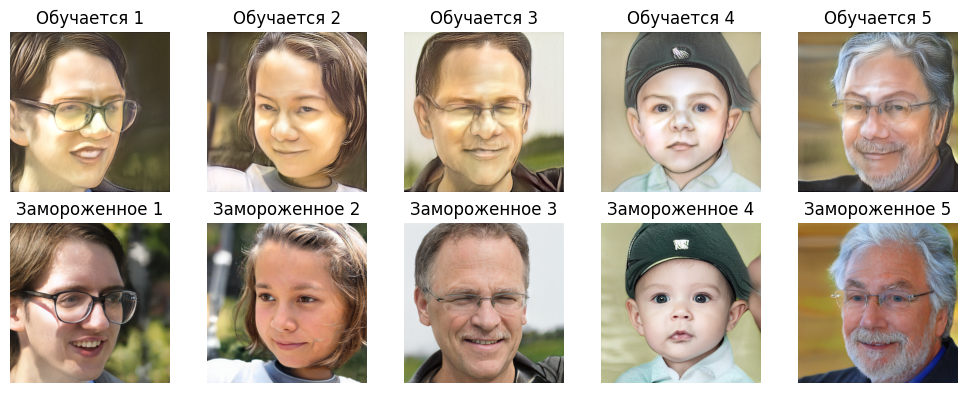


--- Шаг 250: Пересчёт важности слоёв ---

Анализ завершен. Выбрано для обучения 27 логических модулей (всего параметров: 122).
Активные слои: ['convs.9', 'to_rgbs.2', 'convs.2', 'to_rgbs.4', 'convs.4']...
Шаг 250: Тренировочный лосс = 4.3594


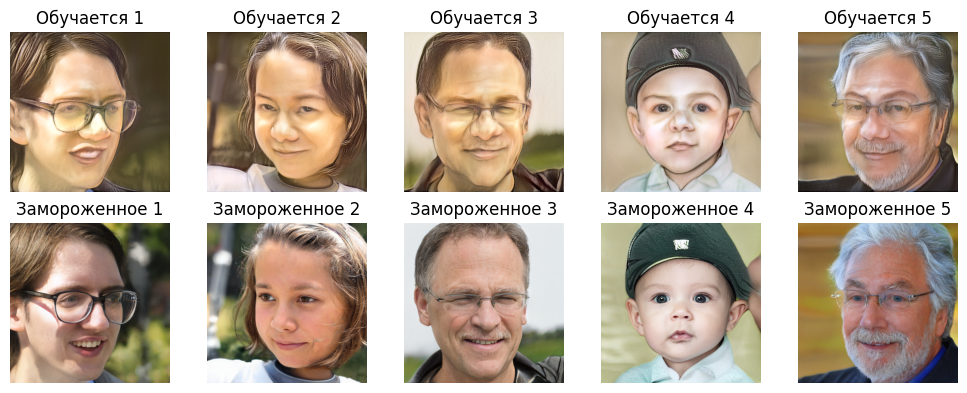

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, ExponentialLR

DIRECTION_LOSS_INTERVAL = 50 # Как часто пересчитываем, какие модули оставлять активными
NUM_TRAINABLE_LAYERS = 27    # Сколько модулей оставляем активными

BATCH_SIZE = 10
optimizer_g = optim.AdamW(
    generator_trainable.parameters(),
    lr=1e-3*5,
    betas=(0.9, 0.999)
)



num_steps = 300  # количество шагов оптимизации

scheduler = CosineAnnealingLR(optimizer_g, T_max=num_steps)
batch = generate_latent_batch(BATCH_SIZE, device, generator_frozen.style)
NUM_VIZ_SAMPLES = 5
fixed_latent_batch_for_viz = generate_latent_batch(NUM_VIZ_SAMPLES, device, generator_frozen.style)
torch.backends.cudnn.benchmark = True
torch.set_grad_enabled(True)
# Не забудьте сохранять лоссы для дальнейшей визуализации!
losses = {'clip_selection': [], 'training': []}

for step in range(num_steps):
    torch.cuda.empty_cache()

    if step % DIRECTION_LOSS_INTERVAL == 0:
        print(f"\n--- Шаг {step}: Пересчёт важности слоёв ---")
        latent = batch[np.random.randint(0, BATCH_SIZE)].unsqueeze(0)
        for param in generator_trainable.parameters():
            param.requires_grad_(True)
        generator_trainable.zero_grad()
        img_for_analysis, _ = generator_trainable([latent], input_is_latent=True, randomize_noise=True)

        selection_loss, active_layers_names = analyze_and_set_layers(
            generator_trainable,
            img_for_analysis,
            prompt2,
            clip_loss,
            num_trainable=NUM_TRAINABLE_LAYERS
        )
        losses['clip_selection'].append(selection_loss)
        print(f"Активные слои: {active_layers_names[:5]}...") # Выведем несколько для проверки

        current_lr = optimizer_g.param_groups[0]['lr']
        #насколько я поняла, после перезаморозки лучше заново инициализировать оптимайзер
        optimizer_g = optim.Adam(
            filter(lambda p: p.requires_grad, generator_trainable.parameters()),
            lr=current_lr, # Используем текущий LR
            betas=(0.9, 0.999)
        )
        # T_max для scheduler также должен учитывать оставшиеся шаги
        scheduler = CosineAnnealingLR(optimizer_g, T_max=num_steps - step)

    optimizer_g.zero_grad()


    lambda_directional = 10.0 # Вес для directional loss, увеличила, т к модель лениво добавляла признаки
    lambda_target = 0.0 #часть лосса с clip вообще по статье не нужна, но я экспериментировала и сейчас эту часть лосса просто занулила
    total_loss = 0
    for i in range(BATCH_SIZE):
      latent_i = batch[i:i+1]

      img_gen_i, _ = generator_trainable([latent_i], input_is_latent=True, randomize_noise=True)

      with torch.no_grad():
          img_gen_frozen_i, _ = generator_frozen([latent_i], input_is_latent=True, randomize_noise=True)

      current_loss = direct_loss(text_in, text_out, img_gen_i, img_gen_frozen_i, beta=0.1)
      clip_image = normalize(resize(img_gen_i))
      current_clip_loss = clip_loss(clip_image, text_out)

      total_loss += (lambda_directional * current_loss) + (lambda_target * current_clip_loss)

      # Явное удаление тензоров, на всякий случай, так как при моем размере батча могут возникнуть проблемы с памятью
      del img_gen_i, img_gen_frozen_i, clip_image, current_loss, current_clip_loss
      torch.cuda.empty_cache() # Очистка кэша после каждого элемента батча
    training_loss = total_loss / BATCH_SIZE
    training_loss.backward()
    optimizer_g.step()

    scheduler.step()
    losses['training'].append(training_loss.item())

    # Визуализация и вывод потерь
    if step % 50 == 0:
        print(f"Шаг {step}: Тренировочный лосс = {training_loss.item():.4f}")

        # Генерация изображений с ФИКСИРОВАННЫМИ латентными векторами для визуализации
        with torch.no_grad():
            img_frozen_batch, _ = generator_frozen(
                [fixed_latent_batch_for_viz],
                input_is_latent=True,
                randomize_noise=False
            )

            generator_trainable.eval()
            img_trainable_batch, _ = generator_trainable(
                [fixed_latent_batch_for_viz],
                input_is_latent=True,
                randomize_noise=False
            )
            generator_trainable.train()


        fig, axs = plt.subplots(2, NUM_VIZ_SAMPLES, figsize=(2 * NUM_VIZ_SAMPLES, 4))

        def prepare_img(img_tensor):
            img = img_tensor.cpu().detach().clip(-1, 1).permute(1, 2, 0)
            return (img + 1) / 2

        for i in range(NUM_VIZ_SAMPLES):
            axs[0, i].imshow(prepare_img(img_trainable_batch[i]))
            axs[0, i].set_title(f"Обучается {i+1}")
            axs[0, i].axis('off')

        for i in range(NUM_VIZ_SAMPLES):
            axs[1, i].imshow(prepare_img(img_frozen_batch[i]))
            axs[1, i].set_title(f"Замороженное {i+1}")
            axs[1, i].axis('off')

        plt.tight_layout()
        plt.show()

        #также стараемся беречь память при каждом удобном случае
        del img_frozen_batch, img_trainable_batch, fig, axs
        torch.cuda.empty_cache()

In [ ]:
def save_model_weights(model, path, filename="trained_generator_sketch.pt"):
    """
    Сохраняет state_dict модели PyTorch.

    :param model: Модель PyTorch (например, generator_trainable).
    :param path: Директория для сохранения файла.
    :param filename: Имя файла для сохранения весов.
    """
    full_path = os.path.join(path, filename)
    # Рекомендуется сохранять state_dict, а не всю модель
    torch.save(model.state_dict(), full_path)
    print(f"Веса модели сохранены в: {full_path}")
    return full_path

In [ ]:
full_path = save_model_weights(generator_trainable, save_dir, f"trained_generator_sketch.pt")

Веса модели сохранены в: results/trained_generator_sketch.pt


In [ ]:
def load_model_weights(model, path, device):
    """
    Загружает state_dict модели PyTorch.

    :param model: Инстанция модели PyTorch, в которую нужно загрузить веса.
    :param path: Полный путь к файлу с весами.
    :param device: Устройство (cuda/cpu) для map_location.
    :return: Модель с загруженными весами.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Файл весов не найден по пути: {path}")

    # Загружаем state_dict
    state_dict = torch.load(path, map_location=device) # Use the passed device

    model.load_state_dict(state_dict)
    print(f"Веса модели успешно загружены из: {path}")
    return model

model = load_model_weights(generator_trainable, 'results/trained_generator_sketch.pt', device)

Веса модели успешно загружены из: results/trained_generator_sketch.pt


In [ ]:
def upload_file_to_drive(local_file_path, drive_folder_id=None):
    """
    Загружает файл на Google Drive.

    :param local_file_path: Путь к файлу на локальном диске Colab.
    :param drive_folder_id: ID папки на Google Drive, куда загружать.
                            Если None, загружает в корневую папку.
    """
    print("Authenticating to Google Drive for upload...")
    auth.authenticate_user()
    gauth = GoogleAuth()
    try:
        gauth.credentials = GoogleCredentials.get_application_default()
    except Exception as e:
        print(f"Error getting application default credentials: {e}")
        print("Attempting direct Colab auth for PyDrive2...")
        gauth.auth_method = 'colab'
        gauth.Authenticate()

    drive = GoogleDrive(gauth)


    file_title = os.path.basename(local_file_path)
    print(f"Загрузка {file_title} на Google Drive...")

    file_metadata = {'title': file_title}
    if drive_folder_id:
        file_metadata['parents'] = [{'id': drive_folder_id}]

    gfile = drive.CreateFile(file_metadata)
    gfile.SetContentFile(local_file_path)
    gfile.Upload()

    print(f"Файл '{file_title}' успешно загружен на Google Drive (ID: {gfile['id']}).")
    return gfile['id']

uploaded_file_id = upload_file_to_drive(full_path)

Authenticating to Google Drive for upload...
Загрузка trained_generator_sketch.pt на Google Drive...
Файл 'trained_generator_sketch.pt' успешно загружен на Google Drive (ID: 1WN4u3r14-KB36YkNOhmzPS998ag82R3c).


Запуск валидационного пайплайна с моделью: results/trained_generator_sketch.pt
Исходный генератор загружен и заморожен.
Веса модели успешно загружены из: results/trained_generator_sketch.pt
Обученный генератор загружен из results/trained_generator_sketch.pt.

--- Визуализация трансформации: 'photo' -> 'light sketch' ---


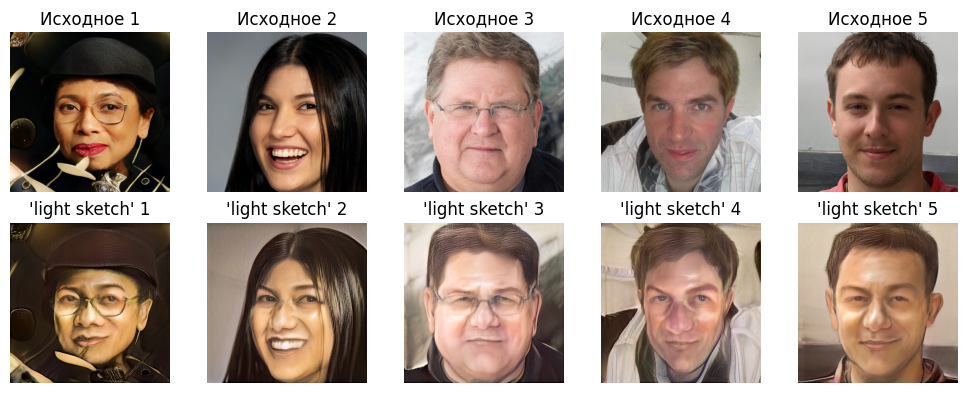

Валидационный пайплайн завершен.


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

resize = Resize((224, 224))

normalize = Normalize(mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])

def generate_latent_batch(batch_size, device, generator_style_network):
    """
    Генерирует батч латентных векторов в W+ пространстве.
    Использует generator_style_network (generator.style) для отображения Z -> W+.
    """
    latent_z = torch.randn(batch_size, 512, device=device)
    with torch.no_grad():
        latent_w_plus = generator_style_network(latent_z)
    return latent_w_plus.detach().clone()
def tensor_to_image(tensor):
    """
    Преобразует тензор изображения из формата [-1, 1] в numpy [0, 1] для визуализации.
    """
    img = tensor[0].permute(1, 2, 0).cpu().numpy()
    img = (img + 1) / 2
    img = np.clip(img, 0, 1)
    return img

def visualize_transformation(generator_original, generator_transformed,
                             latent_batch, prompt1, prompt2,
                             num_samples=5):
    """
    Визуализирует изменения, примененные обученным генератором.

    :param generator_original: Исходный (замороженный) генератор.
    :param generator_transformed: Обученный (измененный) генератор.
    :param latent_batch: Батч латентных векторов для генерации.
    :param prompt1: Исходный текстовый промпт.
    :param prompt2: Целевой текстовый промпт.
    :param num_samples: Количество изображений для визуализации.
    """
    print(f"\n--- Визуализация трансформации: '{prompt1}' -> '{prompt2}' ---")

    generator_original.eval()
    generator_transformed.eval()

    with torch.no_grad():
        # Генерируем изображения исходным генератором
        original_images, _ = generator_original(
            [latent_batch[:num_samples]], input_is_latent=True, randomize_noise=False
        )
        # Генерируем изображения трансформированным генератором
        transformed_images, _ = generator_transformed(
            [latent_batch[:num_samples]], input_is_latent=True, randomize_noise=False
        )

    fig, axs = plt.subplots(2, num_samples, figsize=(2 * num_samples, 4))

    for i in range(num_samples):
        # Исходные изображения (верхний ряд)
        axs[0, i].imshow(tensor_to_image(original_images[i].unsqueeze(0)))
        axs[0, i].set_title(f"Исходное {i+1}")
        axs[0, i].axis('off')

        # Измененные изображения (нижний ряд)
        axs[1, i].imshow(tensor_to_image(transformed_images[i].unsqueeze(0)))
        axs[1, i].set_title(f"'{prompt2}' {i+1}")
        axs[1, i].axis('off')

    plt.tight_layout()
    plt.show()

    generator_original.train() # Возвращаем в train, если они будут использоваться далее в обучении
    generator_transformed.train() # Возвращаем в train

# --- Основной скрипт валидации ---
def run_validation_pipeline(trained_model_path, original_model_filename,
                            num_viz_samples=5, target_prompt="light sketch", source_prompt="photo"):

    print(f"Запуск валидационного пайплайна с моделью: {trained_model_path}")

    current_dir = os.getcwd()
    original_model_path = os.path.join(current_dir, original_model_filename)

    global latent_dim, device # Убедитесь, что они определены

    generator_original = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)
    original_state_dict = torch.load(original_model_path, map_location=device)
    generator_original.load_state_dict(original_state_dict['g_ema'] if 'g_ema' in original_state_dict else original_state_dict)
    generator_original.eval() # Переводим в режим оценки
    for param in generator_original.parameters(): # Замораживаем на всякий случай
        param.requires_grad_(False)
    print("Исходный генератор загружен и заморожен.")

    generator_trained = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)
    load_model_weights(generator_trained, trained_model_path, device) # Pass the device argument
    generator_trained.eval() # Важно для инференса
    print(f"Обученный генератор загружен из {trained_model_path}.")

    fixed_latent_batch_for_viz = generate_latent_batch(num_viz_samples, device, generator_original.style)

    visualize_transformation(generator_original, generator_trained,
                             fixed_latent_batch_for_viz, source_prompt, target_prompt,
                             num_samples=num_viz_samples)

    print("Валидационный пайплайн завершен.")

run_validation_pipeline(
    trained_model_path='results/trained_generator_sketch.pt',
    original_model_filename='stylegan2-ffhq-config-f.pt',
    num_viz_samples=5,
    target_prompt="light sketch",
    source_prompt="photo"
 )